In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("hosseinbadrnezhad/human-faces-dataset-male-female-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'human-faces-dataset-male-female-classification' dataset.
Path to dataset files: /kaggle/input/human-faces-dataset-male-female-classification
Contents of base_path (/kaggle/input):
['human-faces-dataset-male-female-classification']
Contents of path (/kaggle/input/human-faces-dataset-male-female-classification):
['men', 'women']


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Output path for the split dataset
output_folder = "dataset_split"

# Split the dataset: 80% Train, 20% Val
# If you want 3 parts (Train/Val/Test), change ratio to (.8, .1, .1)
splitfolders.ratio(path, output=output_folder, seed=1337, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Split completed! New data is located at: {output_folder}")

Copying files: 2000 files [00:19, 102.40 files/s]

Split completed! New data is located at: dataset_split


In [ ]:
import os

def count_files(directory):
    for root, dirs, files in os.walk(directory):
        if not dirs: # Only print leaf directories
            print(f"{root}: {len(files)} images")

print("Verifying image counts after split:")
count_files(output_folder)

Verifying image counts after split:
dataset_split/val/women: 255 images
dataset_split/val/men: 146 images
dataset_split/train/women: 1018 images
dataset_split/train/men: 581 images


In [ ]:
import tensorflow as tf

# Check if GPU is available
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Setting memory growth to avoid allocating all memory at once
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU is not available. Training will proceed on CPU (much slower).")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras import layers, models, optimizers

# Configuration
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 10

# Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(output_folder, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# Build Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze base layers

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train Model
print("Starting training...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

Found 1599 images belonging to 2 classes.
Found 401 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting training...
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8812 - loss: 0.2800 - val_accuracy: 0.9451 - val_loss: 0.1203
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9181 - loss: 0.1946 - val_accuracy: 0.9476 - val_loss: 0.1084
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9250 - loss: 0.1771 - val_accuracy: 0.9551 - val_loss: 0.1062
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9287 - loss: 0.1693 - val_accuracy: 0.9526 - val_loss: 0.1266
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9293 - loss: 0.1738 - val_accuracy: 0.9327 - val_loss: 0.1600
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9306 - loss: 0.1675 - val_accuracy: 0.9551 - val_loss: 0.1084
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9393 - loss: 0.1629 - va

In [ ]:
# Summarize Training Results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
model.summary()

Final Training Accuracy: 0.9350
Final Validation Accuracy: 0.9501


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,589,989 (86.17 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

 Optimizer params: 524,804 (2.00 MB)

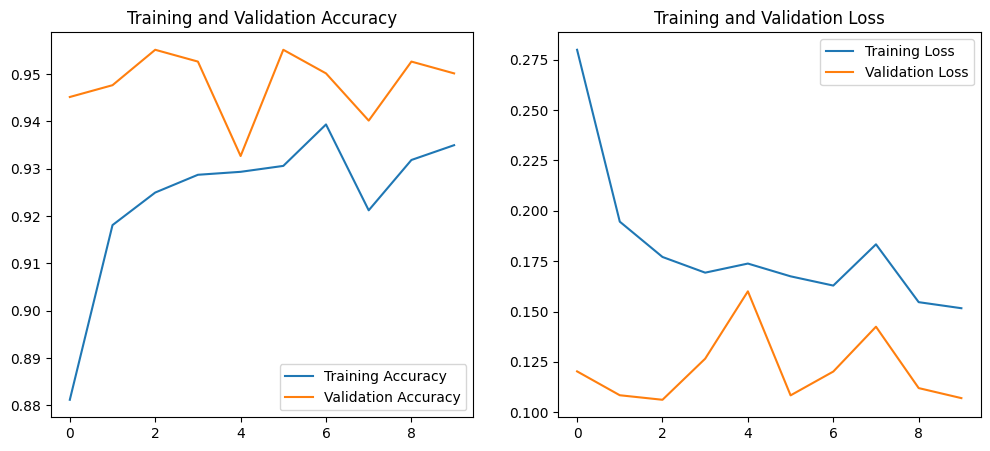

In [ ]:
import matplotlib.pyplot as plt

# Plot Training and Validation curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()